# Gradient Pattern Analysis (GPA) - Basic Usage Example

This notebook demonstrates the basic workflow of the Gradient Pattern Analysis (GPA) method.

The GPA method characterizes spatial patterns through the analysis of gradient fields and gradient moments.

The main steps are:

1. Generate or load a 2D scalar field.
2. Compute the gradient field.
3. Analyze gradient directions and magnitudes.
4. Calculate GPA moments (currently only G2 is implemented; G1, G3, and G4 are not yet available).
5. Visualize the obtained results.

---

## Author

**Carlos Eduardo Falandes**

M.Sc. Candidate in Applied Computing  
National Institute for Space Research (INPE), Brazil

**Master's Dissertation:**  
*Gradient Pattern Analysis (GPA): Two New Applications for Pattern Characterization in Physics of Extreme Events and Extragalactic Astronomy*

**Contact:** carloseduardofalandes@gmail.com

This notebook is part of the GPA Python implementation developed during the author's master's research. It is intended as a basic introduction to the library and demonstrates the fundamental workflow for applying the Gradient Pattern Analysis method to two-dimensional scalar fields.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt

from gpa.gpa import GPA

# Gradient Pattern Analysis (GPA) - Basic Examples

This notebook demonstrates the basic usage of the Gradient Pattern Analysis (GPA) method.

The objective is to illustrate how GPA characterizes different spatial patterns through the analysis of gradient fields and gradient moments.

Three synthetic patterns are analyzed:

1. Asymmetric pattern
2. Symmetric pattern
3. Laminar pattern

These examples provide a simple visualization of how the GPA method responds to different spatial organizations.

## Matrix visualization

A helper function is created to visualize the synthetic patterns.

Each matrix element represents the intensity value of a spatial position.

In [2]:
def plot_matrix(matrix, title):
    plt.figure(figsize=(5, 5))

    plt.imshow(
        matrix,
        cmap="viridis",
        origin="lower"
    )

    plt.colorbar(label="Value")

    plt.title(title)

    plt.xticks(range(matrix.shape[1]))
    plt.yticks(range(matrix.shape[0]))

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(
                j,
                i,
                str(matrix[i, j]),
                ha="center",
                va="center",
                color="white",
                fontsize=10
            )

    plt.show()

## Asymmetric Pattern

The asymmetric pattern is generated by randomly distributing values inside the matrix.

This creates a spatial structure without a predefined organization or symmetry.

The objective is to evaluate how GPA describes irregular spatial distributions.

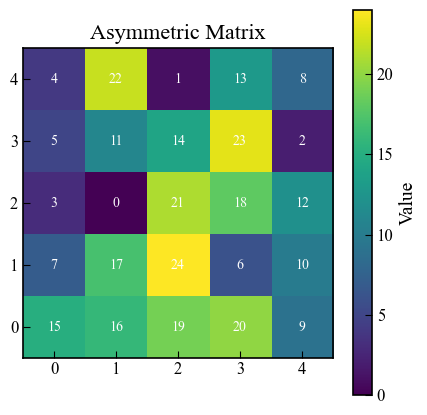

In [3]:
def create_asymmetric_matrix(n, seed=None):
    """
    Creates an n x n matrix with values from 0 to n²-1
    randomly distributed.
    """
    rng = np.random.default_rng(seed)

    values = np.arange(n * n)

    rng.shuffle(values)

    return values.reshape((n, n))


asymmetric = create_asymmetric_matrix(
    5,
    seed=42
)


plot_matrix(
    asymmetric,
    "Asymmetric Matrix"
)

## Symmetric Pattern

The symmetric matrix represents a spatially organized structure.

Values are generated according to the distance from the center of the matrix, producing radial symmetry.

This type of structure is expected to generate a more organized gradient field.

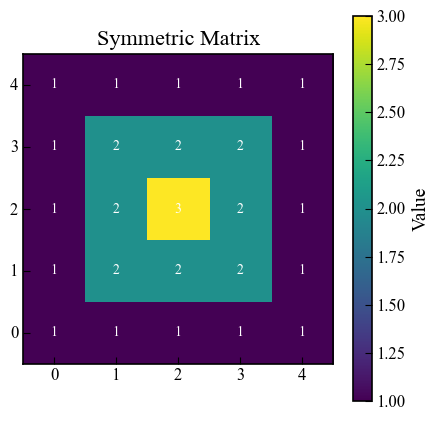

In [4]:
def create_symmetric_matrix(n):

    center = (n - 1) / 2

    matrix = np.zeros(
        (n, n),
        dtype=int
    )

    for i in range(n):
        for j in range(n):

            distance = max(
                abs(i - center),
                abs(j - center)
            )

            matrix[i, j] = int(
                center + 1 - distance
            )

    return matrix


symmetric = create_symmetric_matrix(5)


plot_matrix(
    symmetric,
    "Symmetric Matrix"
)

## Laminar Pattern

The laminar pattern represents an ordered structure with a continuous gradient.

Values increase sequentially along the matrix, producing aligned gradient vectors.

This type of pattern is useful for testing GPA response to highly organized structures.

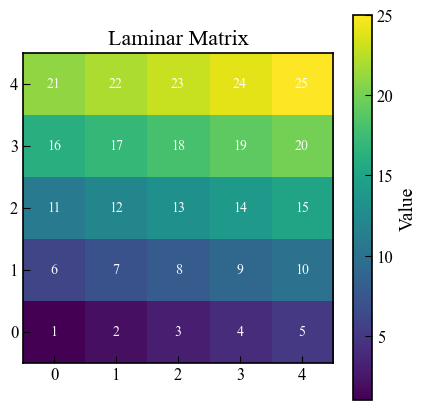

In [5]:
def create_laminar_matrix(n):
    """
    Creates an n x n matrix with increasing values row by row.
    """

    return np.arange(
        1,
        n*n + 1
    ).reshape(n, n)


laminar = create_laminar_matrix(5)


plot_matrix(
    laminar,
    "Laminar Matrix"
)

# Applying Gradient Pattern Analysis

The GPA object receives a two-dimensional scalar field.

After initialization, the spatial position used as reference for the analysis is defined using `setPosition()`.

The `evaluate()` method computes the selected gradient moments.

In this example, the second gradient moment (G2) is calculated.

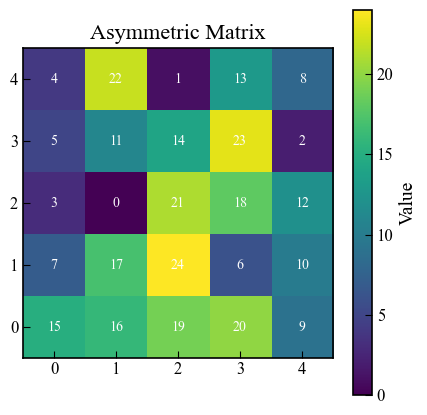

oi


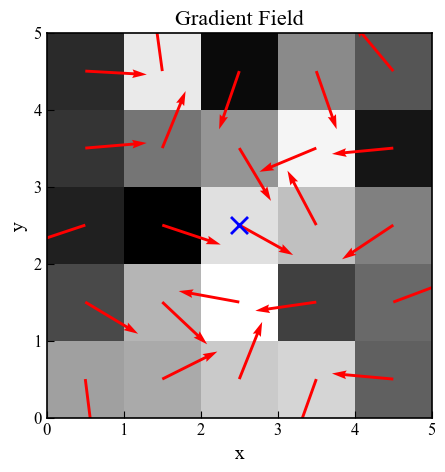

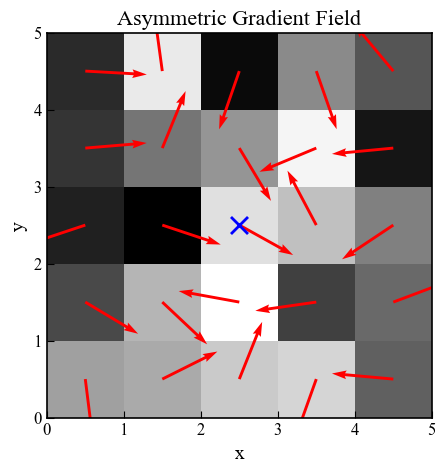

{'G2': np.float32(1.8244594)}

In [6]:
plot_matrix(
    asymmetric,
    "Asymmetric Matrix"
)

gpaObject = GPA(asymmetric)

gpaObject.setPosition(
    2,
    2
)

results = gpaObject.evaluate(
    mtol=0.02,
    ftol=0.03,
    ptol=0.01,
    moments=("G2")
)

gpaObject.plot_gradient_field()
gpaObject.plot_asymmetric_gradient_field()
results

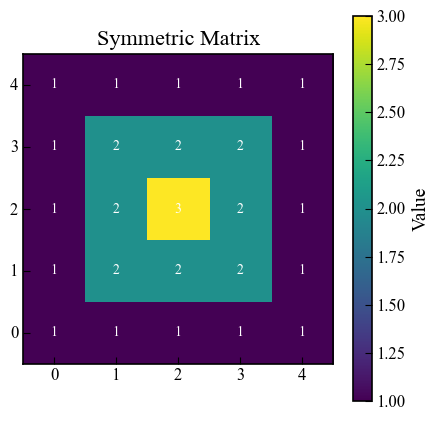

oi


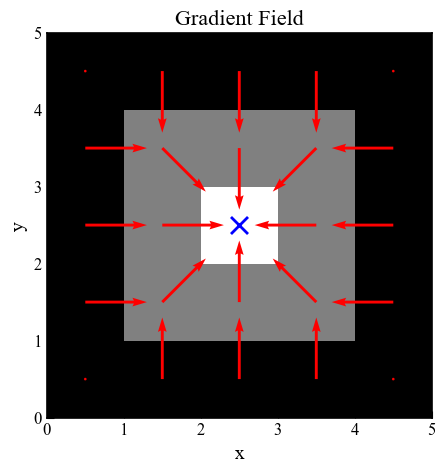

No asymmetric gradient vectors remaining.


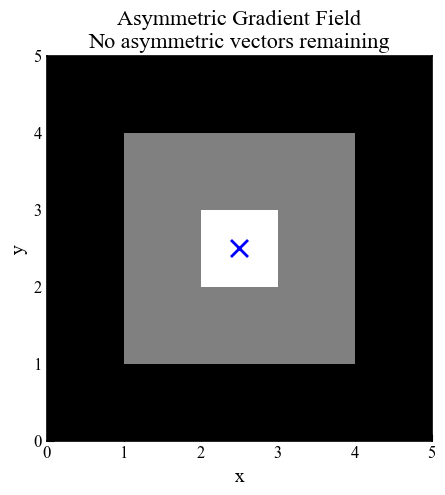

{'G2': 0.0}

In [7]:
plot_matrix(
    symmetric,
    "Symmetric Matrix"
)

gpaObject = GPA(symmetric)

gpaObject.setPosition(
    2,
    2
)

results = gpaObject.evaluate(
    mtol=0.5,
    ftol=0.3,
    ptol=0.3,
    moments=("G2")
)

gpaObject.plot_gradient_field()
gpaObject.plot_asymmetric_gradient_field()

results

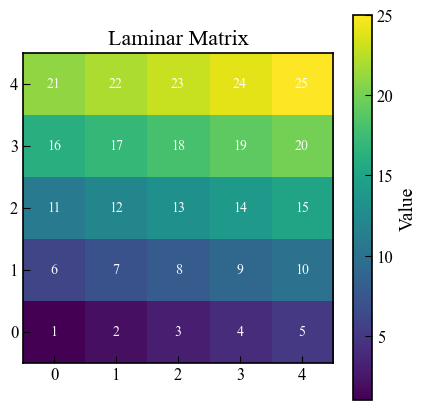

oi


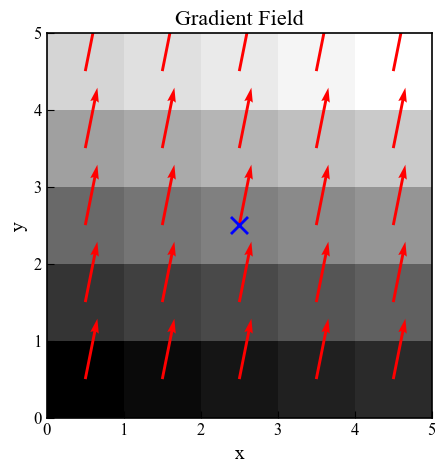

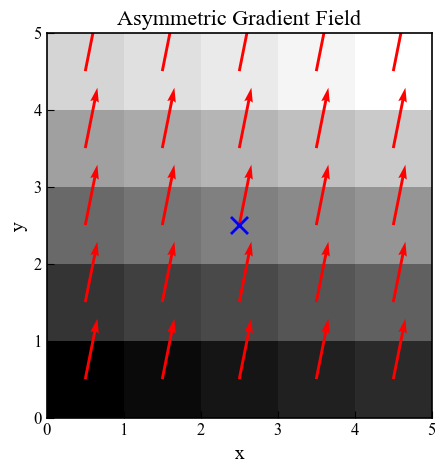

{'G2': np.float32(1.0000002)}

In [8]:
plot_matrix(
    laminar,
    "Laminar Matrix"
)

gpaObject = GPA(laminar)

gpaObject.setPosition(
    2,
    2
)

results = gpaObject.evaluate(
    mtol=0.02,
    ftol=0.03,
    ptol=0.01,
    moments=("G2")
)

gpaObject.plot_gradient_field()
gpaObject.plot_asymmetric_gradient_field()

results

## Comparing GPA moments

The following experiment applies GPA to all generated patterns.

The gradient moments provide quantitative descriptors of the spatial organization of each pattern.

In [9]:
def run_gpa(matrix, name):

    gpa = GPA(matrix)

    result = gpa.evaluate(
        mtol=0.02,
        ftol=0.03,
        ptol=0.01,
        moments=("G1","G2","G3","G4")
    )

    print(name)
    print(result)

    return result

In [10]:
results = {}

results["Asymmetric"] = run_gpa(
    asymmetric,
    "Asymmetric"
)

results["Symmetric"] = run_gpa(
    symmetric,
    "Symmetric"
)

results["Laminar"] = run_gpa(
    laminar,
    "Laminar"
)

oi
Asymmetric
{'G1': None, 'G2': np.float32(1.8244594), 'G3': None, 'G4': None}
oi
Symmetric
{'G1': None, 'G2': 0.0, 'G3': None, 'G4': None}
oi
Laminar
{'G1': None, 'G2': np.float32(1.0000002), 'G3': None, 'G4': None}


# Discussion

The Gradient Pattern Analysis (GPA) results show that the second gradient moment (G2) is able to distinguish different spatial organizations in the synthetic patterns.

For the **asymmetric pattern**, the obtained value of **G2 ≈ 1.82** indicates a strong degree of gradient asymmetry. Since the matrix values are randomly distributed, the resulting gradient field does not present a preferential organization, leading to a larger imbalance in the spatial arrangement of gradient vectors.

The **symmetric pattern** presents **G2 = 0**, as expected for a perfectly organized structure with radial symmetry. In this case, the gradient contributions are balanced around the reference position, resulting in no measurable asymmetry according to the G2 descriptor.

The **laminar pattern** produces an intermediate value of **G2 ≈ 1.0**. Although the structure is highly organized, the continuous directional variation of the intensity values generates a preferential gradient orientation, resulting in a non-zero G2 value. This indicates that GPA is sensitive not only to disorder, but also to organized directional structures.

These results demonstrate the ability of GPA, particularly the second gradient moment (G2), to quantify differences between symmetric, asymmetric, and ordered spatial patterns. The method provides a quantitative description of structural organization based on the spatial distribution of gradients, supporting its application in more complex systems such as multifractal fields, astronomical images, and other nonlinear structures.

## Example: Using a Mask

In [11]:
matrix = np.random.randint(
    0,
    10,
    (15, 15)
).astype(np.float32)
symmetric = create_symmetric_matrix(5).astype(np.float32)

matrix[5:10, 5:10] = symmetric

mask = np.zeros_like(matrix, dtype=np.uint8)
mask[6:9, 6:9] = 1

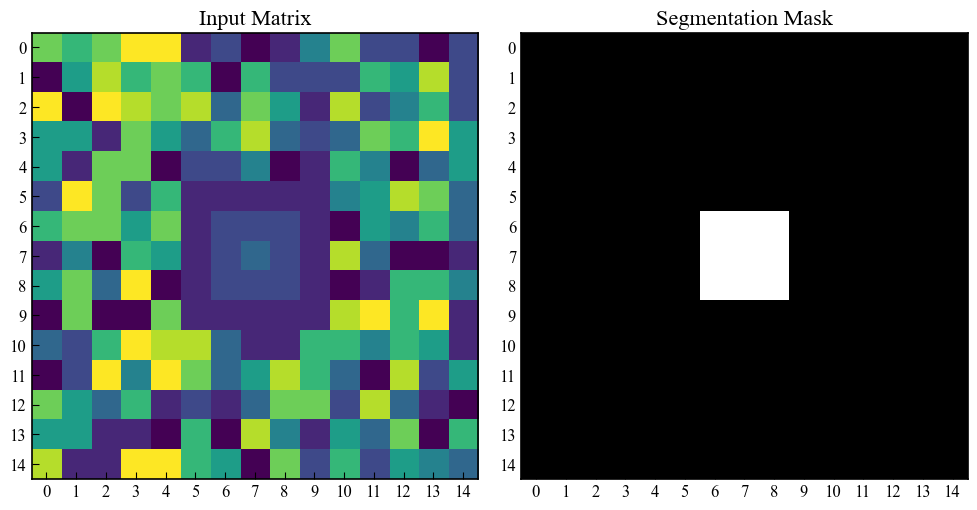

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(matrix, cmap="viridis")
ax[0].set_title("Input Matrix")
ax[0].set_xticks(range(matrix.shape[1]))
ax[0].set_yticks(range(matrix.shape[0]))

ax[1].imshow(mask, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Segmentation Mask")
ax[1].set_xticks(range(mask.shape[1]))
ax[1].set_yticks(range(mask.shape[0]))

plt.tight_layout()
plt.show()

In [13]:
gpaObject = GPA(matrix)
gpaObject.setPosition(7, 7)
ga = gpaObject.evaluate(mtol=0.01, ftol=0.02, ptol=0.01, mask=mask)
ga

oi


{'G1': None, 'G2': 0.0, 'G3': None, 'G4': None}

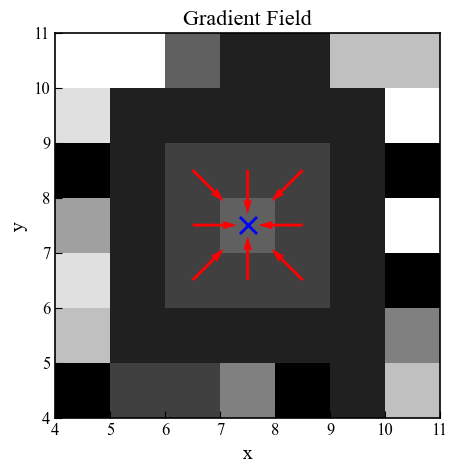

No asymmetric gradient vectors remaining.


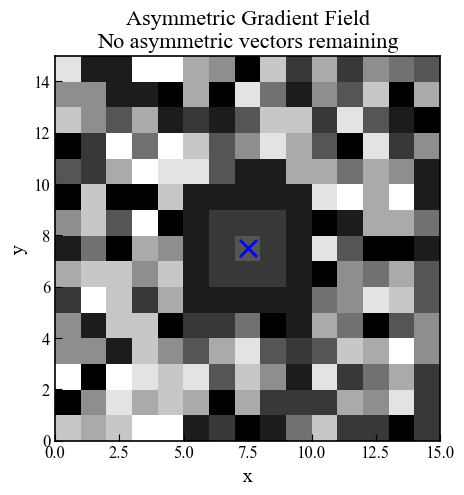

In [14]:
gpaObject.plot_gradient_field()
gpaObject.plot_asymmetric_gradient_field()
